
# Joint flux maps example


Run on branch https://github.com/QRemy/gammapy/tree/joint_ts_experimental

In [1]:
%%javascript
IPython.OutputArea.auto_scroll_threshold = -1






In [2]:
#use full width
from IPython.core.display import HTML
from IPython.display import display
display(HTML("<style>.container { width:100% !important; }</style>"))



In [3]:
#toogle warning messages
def toogle_output():
    return HTML('''<script>
    code_show_err=true; 
    function code_toggle_err() {
     if (code_show_err){
     $('div.output_stderr').hide();
     } else {
     $('div.output_stderr').show();
     }
     code_show_err = !code_show_err
    } 
    $( document ).ready(code_toggle_err);
    </script>
    To toggle on/off output_stderr, click <a href="javascript:code_toggle_err()">here</a>.''')




In [4]:
#import
import numpy as np
from astropy import units as u
from astropy.coordinates import SkyCoord
from regions import CircleSkyRegion
import matplotlib.pyplot as plt
import matplotlib as mpl
from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import Datasets, MapDataset, SpectrumDataset
from gammapy.makers import (
    DatasetsMaker,
    FoVBackgroundMaker,
    MapDatasetMaker,
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
)
from gammapy.makers.utils import make_effective_livetime_map, make_observation_time_map
from gammapy.maps import MapAxis, RegionGeom, WcsGeom, Map
from gammapy.modeling.models import PointSpatialModel, GeneralizedGaussianSpatialModel, SkyModel, PowerLawSpectralModel, PiecewiseNormSpectralModel
from gammapy.modeling import Fit
from gammapy .estimators import TSMapEstimator

## Get datasets



In [5]:
target_name = "HESS J1514-591"
position = SkyCoord.from_name(target_name).galactic
target_name = "MSH 15-52"

In [6]:
energies = 10**np.arange(-0.4, 2.1, 0.1)
energy_axis = MapAxis(energies, name="energy", unit="TeV", interp="log")
energies_true  = 10**np.arange(-1, 2.4, 0.1)
energy_axis_true = MapAxis(energies_true, name="energy_true", unit="TeV", interp="log")


geom = WcsGeom.create(
    skydir=position,
    axes=[energy_axis],
    width=3. * u.deg,
    binsz=0.03 * u.deg,
    frame="galactic",
)


In [7]:
#get observations 

data_store = DataStore.from_dir("$GAMMAPY_DATA/hess-dl3-dr1")
selection = data_store.obs_table["TARGET_NAME"]==target_name
obs_ids = data_store.obs_table["OBS_ID"][selection]
observations = data_store.get_observations(obs_ids)


In [8]:
 data_store.obs_table[selection][:10]

OBS_ID,RA_PNT,DEC_PNT,GLON_PNT,GLAT_PNT,ZEN_PNT,ALT_PNT,AZ_PNT,OBJECT,RA_OBJ,DEC_OBJ,OFFSET_OBJ,ONTIME,LIVETIME,DEADC,TSTART,TSTOP,DATE-OBS,TIME-OBS,DATE-END,TIME-END,N_TELS,TELLIST,QUALITY,MUONEFF,EVENT_COUNT,TARGET_NAME,TARGET_TAG,TARGET_OFFSET,SAFE_ENERGY_LO,SAFE_ENERGY_HI
,deg,deg,deg,deg,deg,deg,deg,,deg,deg,deg,s,s,,s,s,,,,,,,,,,,,deg,TeV,TeV
int64,float32,float32,float32,float32,float32,float32,float32,bytes18,float32,float32,float32,float32,float32,float32,float64,float64,bytes10,bytes12,bytes10,bytes12,int64,bytes7,int64,float32,int64,bytes21,bytes14,float32,float32,float32
20136,228.6125,-58.771667,320.56754,-0.8857012,38.512962,51.487038,195.73102,MSH15-52,228.6125,-59.271667,0.5,1682.0,1521.0269,0.9042966,101962602.0,101964284.0,2004-03-26,02:57:46.184,2004-03-26,03:25:48.184,4,"1,2,3,4",0,1.2132596,11243,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20137,228.6125,-59.771667,320.04724,-1.7397733,40.21616,49.78384,199.6482,MSH15-52,228.6125,-59.271667,0.5,902.0,819.2054,0.90821,101964441.0,101965343.0,2004-03-26,03:28:25.184,2004-03-26,03:43:27.184,4,"1,2,3,4",0,1.2139559,5693,MSH 15-52,msh1552,0.6156251,0.40738028,100.0
20151,228.6125,-58.771667,320.56754,-0.8857012,37.164658,52.835342,190.97171,custom,228.6125,-59.271667,0.5,1683.0,1530.479,0.9093755,102047232.0,102048915.0,2004-03-27,02:28:16.184,2004-03-27,02:56:19.184,4,"1,2,3,4",0,1.2214733,10722,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20282,228.6125,-58.771667,320.56754,-0.8857012,37.13134,52.86866,169.21602,MSH 15-5-02,228.6125,-59.271667,0.5,1687.0,1543.3231,0.9148329,103678269.0,103679956.0,2004-04-14,23:32:13.184,2004-04-15,00:00:20.184,4,"1,2,3,4",0,1.1495326,11063,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20283,228.6125,-59.771667,320.04724,-1.7397733,36.221436,53.778564,175.77263,MSH 15-5-02,228.6125,-59.271667,0.5,1683.0,1547.8253,0.9196823,103680087.0,103681770.0,2004-04-15,00:02:31.184,2004-04-15,00:30:34.184,4,"1,2,3,4",0,1.1512518,7628,MSH 15-52,msh1552,0.6156251,0.3801894,100.0
20301,228.6125,-58.771667,320.56754,-0.8857012,36.839905,53.160095,171.07347,MSH 15-5-02,228.6125,-59.271667,0.5,1683.0,1534.0626,0.9115048,103764878.0,103766561.0,2004-04-15,23:35:42.184,2004-04-16,00:03:45.184,4,"1,2,3,4",0,1.1503073,11624,MSH 15-52,msh1552,0.38821736,0.40738028,100.0
20302,228.6125,-59.771667,320.04724,-1.7397733,36.11632,53.88368,177.10521,MSH 15-5-02,228.6125,-59.271667,0.5,1682.0,1535.3478,0.9128108,103766698.0,103768380.0,2004-04-16,00:06:02.184,2004-04-16,00:34:04.184,4,"1,2,3,4",0,1.1493496,11794,MSH 15-52,msh1552,0.6156251,0.3801894,100.0
20303,228.6125,-58.771667,320.56754,-0.8857012,36.186012,53.813988,183.91011,MSH 15-5-02,228.6125,-59.271667,0.5,1682.0,1535.1606,0.9126996,103768520.0,103770202.0,2004-04-16,00:36:24.184,2004-04-16,01:04:26.184,4,"1,2,3,4",0,1.1557641,11803,MSH 15-52,msh1552,0.38821736,0.3801894,100.0


In [9]:
#makers

dataset_maker = MapDatasetMaker()
offset_mask_maker = SafeMaskMaker(methods=["offset-max"], offset_max="2. deg")

energy_mask_maker = SafeMaskMaker(methods=["aeff-default", "aeff-max"], aeff_percent=10)

circle = CircleSkyRegion(center=geom.center_skydir, radius=0.6 * u.deg)
exclusion_mask = geom.region_mask([circle], inside=False)


energy = np.concatenate((energy_axis.center[energy_axis.center<25*u.TeV],[energy_axis.edges[-1]]))
print(energy)
bkg_spec = PiecewiseNormSpectralModel(energy)
for p in bkg_spec.parameters:
    p.min = 0 
    p.max = 100
fit = Fit(optimize_opts=dict(strategy=2, tolerance=0.1))
fov_bkg_maker = FoVBackgroundMaker(method="fit", exclusion_mask=exclusion_mask, spectral_model=bkg_spec, fit=fit)
#fov_bkg_maker = FoVBackgroundMaker(method="scale", exclusion_mask=exclusion_mask)


[  0.44668359   0.56234133   0.70794578   0.89125094   1.12201845
   1.41253754   1.77827941   2.23872114   2.81838293   3.54813389
   4.46683592   5.62341325   7.07945784   8.91250938  11.22018454
  14.12537545  17.7827941   22.38721139 100.        ] TeV


In [10]:
#run data reduction
global_dataset = MapDataset.create(geom, energy_axis_true=energy_axis_true)
makers = [dataset_maker, offset_mask_maker, fov_bkg_maker, fov_bkg_maker, energy_mask_maker]  # the order matter
datasets_maker = DatasetsMaker(makers, stack_datasets=False, n_jobs=4)
datasets_maker._apply_cutout = False # force same geom, this should be configurable
datasets = datasets_maker.run(global_dataset, observations)


In [11]:
mask = geom.energy_mask(geom.axes[0].edges[1], geom.axes[0].edges[-2])
#mask &= geom.boundary_mask(0.2*u.deg)
for d in datasets:
    d.mask_fit = mask
    

In [12]:
#select valid datasets
datasets_valid = Datasets()
for d in datasets:
    if np.any(d.mask.data):
        datasets_valid.append(d)
datasets = datasets_valid
del datasets_valid


In [13]:
print(len(datasets))
datasets = Datasets([datasets[_] for _ in [2,3,4,6]]) #4 obs with 2 different pointings
print(len(datasets))


20
4


In [14]:
stacked = datasets.stack_reduce()



In [15]:
fit = Fit(optimize_opts=dict(strategy=2, tolerance=0.1))
bkg_spec.parameters[0].frozen=True
bkg_spec.parameters[-1].frozen=True
fov_bkg_maker = FoVBackgroundMaker(method="fit", exclusion_mask=exclusion_mask, spectral_model=bkg_spec, fit=fit)
stacked = fov_bkg_maker.run(stacked)
stacked.mask_fit = mask


In [16]:
stacked.models.parameters.to_table()

type,name,value,unit,error,min,max,frozen,is_norm,link,prior
str1,str7,float64,str1,float64,float64,float64,bool,bool,str1,str1
,norm_0,1.0000e+00,,0.000e+00,0.000e+00,1.000e+02,True,False,,
,norm_1,1.0000e+00,,2.282e-02,0.000e+00,1.000e+02,False,False,,
,norm_2,1.0000e+00,,3.041e-02,0.000e+00,1.000e+02,False,False,,
,norm_3,1.0000e+00,,3.666e-02,0.000e+00,1.000e+02,False,False,,
,norm_4,1.0000e+00,,4.299e-02,0.000e+00,1.000e+02,False,False,,
,norm_5,1.0000e+00,,5.185e-02,0.000e+00,1.000e+02,False,False,,
...,...,...,...,...,...,...,...,...,...,...
,norm_12,1.0000e+00,,1.091e-01,0.000e+00,1.000e+02,False,False,,
,norm_13,1.0000e+00,,1.443e-01,0.000e+00,1.000e+02,False,False,,


(<WCSAxes: >,
 <Axes: xlabel='Energy [$\\mathrm{TeV}$]', ylabel='Residuals (data - model)'>)

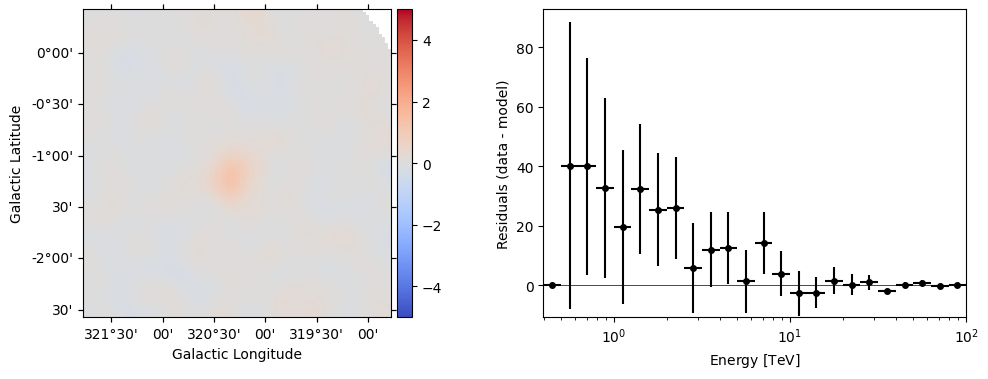

In [17]:
stacked.plot_residuals()

# TS profiles for stacked dataset

In [18]:
from gammapy.estimators.utils import approximate_profile, get_flux_map_from_profile, combine_flux_maps


In [19]:
d = stacked

geom = d.counts.geom.to_image()


            
spatial_model=PointSpatialModel.from_position(geom.center_skydir)
#spatial_model=GeneralizedGaussianSpatialModel(lon_0=geom.center_skydir.galactic.l,lat_0=geom.center_skydir.galactic.b,r_0=geom.pixel_scales.min(),eta=0.1,frame="galactic")

reference_model = SkyModel(spatial_model=spatial_model, spectral_model=PowerLawSpectralModel(index=2.))

energy_edges = d.counts.geom.axes[0].edges
energy_edges = [energy_edges[0], energy_edges[-1]]


toogle_output()

Results from the default estimator

In [20]:
%%time
kernel_width=2*u.deg
estimator_ref = TSMapEstimator(kernel_width=kernel_width,
                           energy_edges=energy_edges,
                           selection_optional=["errn-errp", "ul"],
                           model=reference_model,
                          )
res_ref = estimator_ref.run(d)


CPU times: user 12.2 s, sys: 194 ms, total: 12.4 s
Wall time: 12 s


Results from the estimator with profile computation

In [21]:
%%time
estimator = TSMapEstimator(kernel_width=kernel_width,
                           energy_edges=energy_edges,
                           selection_optional=["stat_scan"],
                           model=reference_model,
                          )
res = estimator.run(d)


CPU times: user 24.5 s, sys: 632 ms, total: 25.1 s
Wall time: 25.1 s


Results (norm, errn, errp, ul) recomputed from the profile

In [22]:
%%time
res_profile = get_flux_map_from_profile(res)


CPU times: user 7.95 s, sys: 4.24 s, total: 12.2 s
Wall time: 12.7 s


Results from the profile approximation computed using the default estimator results

In [23]:
%%time
stat_approx = approximate_profile(res_ref, sqrt_ts_threshold_ul="ignore", dnde_scan_axis=res.stat_scan.geom.axes["dnde"])
res_profile_approx = get_flux_map_from_profile(dict(stat_scan=stat_approx), reference_model=res_ref.reference_model, gti=res_ref.gti, meta=res_ref.meta)

sqrt_ts_stacked = res_ref["sqrt_ts"]

/Users/qremy/Work/GitHub/gammapy/gammapy/estimators/utils.py:1041: RuntimeWarning: divide by zero encountered in log
  stat_approx.data[ij, :, il, ik] = -2 * np.log(


CPU times: user 13.6 s, sys: 9.59 s, total: 23.2 s
Wall time: 24.6 s


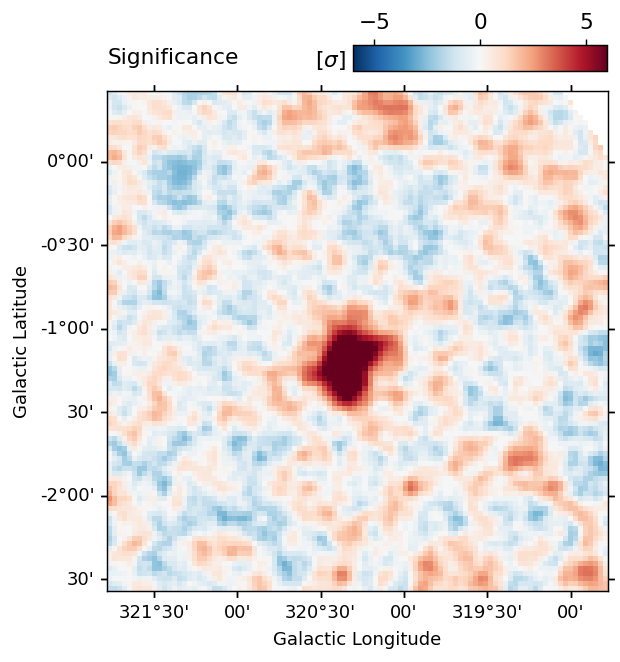

In [24]:
#default
fig = plt.figure(figsize=(13,5), dpi=130)
ax = res_ref["sqrt_ts"].plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);


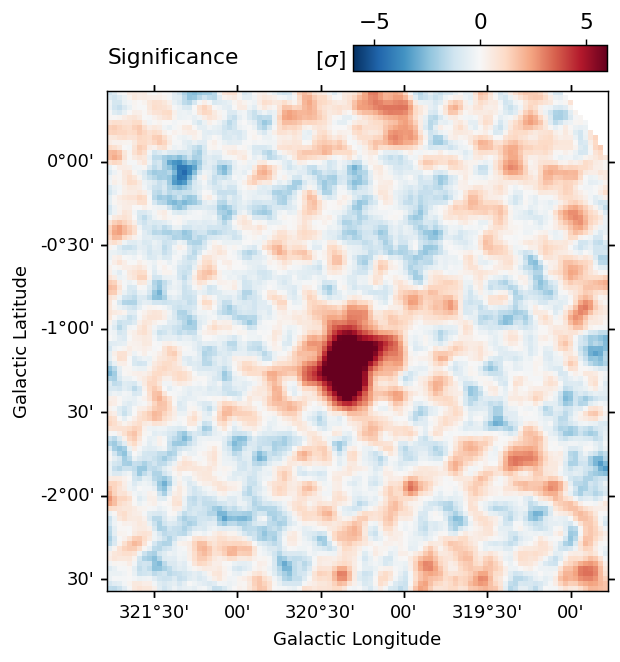

In [25]:
#profile
fig = plt.figure(figsize=(13,5), dpi=130)
ax = res_profile["sqrt_ts"].plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

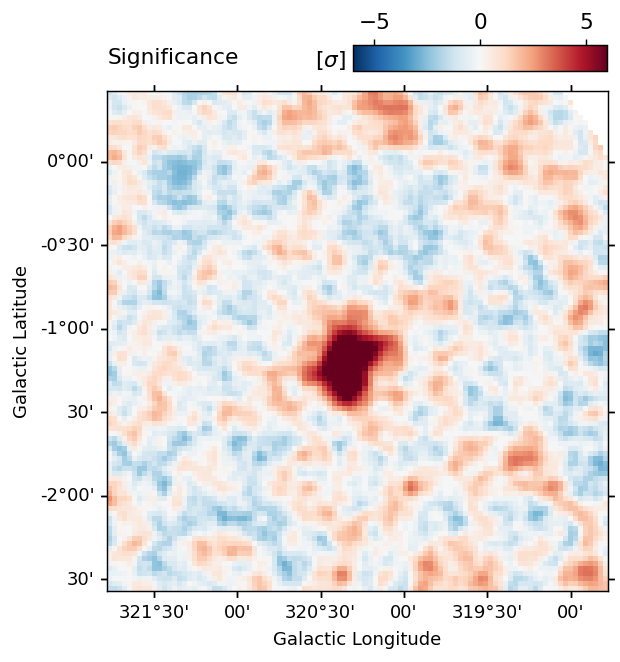

In [26]:
#profile approximation
fig = plt.figure(figsize=(13,5), dpi=130)
ax = res_profile_approx["sqrt_ts"].plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

Results from the gaussian approximation computed using the default estimator results

In [27]:
%%time
result_gauss_approx = combine_flux_maps([res_ref], method="gaussian_errors")


CPU times: user 24.6 ms, sys: 7.8 ms, total: 32.4 ms
Wall time: 10.7 ms


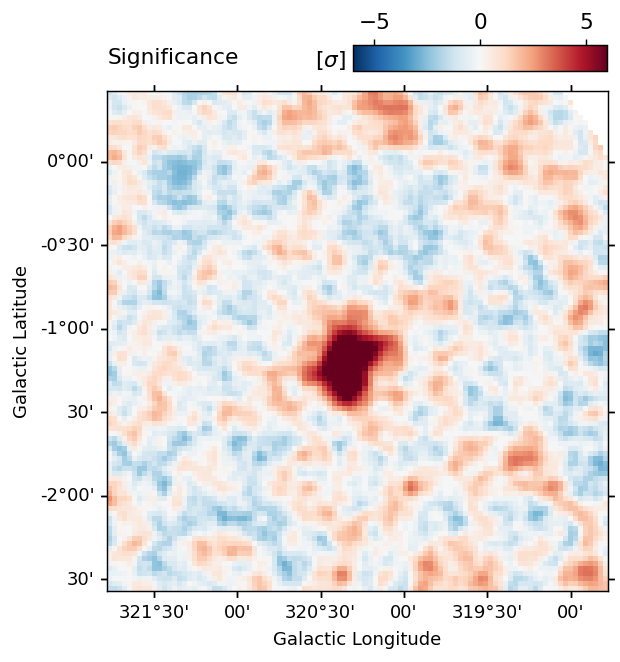

In [28]:
#gaussian approximation
fig = plt.figure(figsize=(13,5), dpi=130)
ax = result_gauss_approx["sqrt_ts"].plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

In [29]:
print("sqrt(TS) max")
print("reference", np.nanmax(res_ref["sqrt_ts"]))
print("profile", np.nanmax(res_profile["sqrt_ts"]))
print("profile_approx", np.nanmax(res_profile_approx["sqrt_ts"]))
print("gauss_approx", np.nanmax(result_gauss_approx["sqrt_ts"]))

sqrt(TS) max
reference 10.421609792878654
profile 10.421535832268868
profile_approx 10.421609792878654
gauss_approx 10.421609792878654


The ts from the gaussian approximation is scaled to match the refrence one as explained below :

### Note on the validty of the gaussian approximation

Here we have the maximum sqrt_ts from the estimator

In [30]:
idx = np.nanargmax(res_ref["sqrt_ts"])
res_ref["sqrt_ts"].data.flatten()[idx]

10.421609792878654

and here we have the maximum sqrt_ts from the gaussian error approximation

In [31]:
import scipy.stats as stats

mean=res_ref["norm"].data.flatten()[idx]
sigma=res_ref["norm_err"].data.flatten()[idx]
ts = -2 * np.log(
            stats.norm.pdf(0, loc=mean, scale=sigma)
            / stats.norm.pdf(mean, loc=mean, scale=sigma)
        )
print(np.sqrt(ts))

7.367823060179161


In [32]:
mean/sigma

7.367823060179161

The ts differ as we are already in the regime where the null hypothesis (0) is outside the validity range of the gaussian approximation.

The `combine_flux_maps` and `approximate_profile`  methods take into account this difference to scale the TS correclty. \
This is donne for each pixel of the map :

In [33]:
ts_diff = res_ref.norm*res_ref.norm/res_ref.norm_err/res_ref.norm_err*(-1) + np.sign(res_ref.norm)*res_ref.ts 

<WCSAxes: >

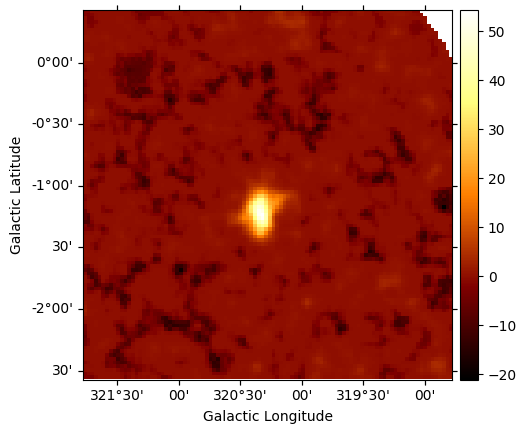

In [34]:
ts_diff.plot(add_cbar=True)


If the null hypothesis is often outside the validity range of the gaussian approximation, has detection significance ever been meaningful or it is just a convention to quote it ?

Looking at the TS profile we can check in which range the gaussian approximation is valid.\
When the number of events is high enough the gaussian approximation remain valid within few sigma so the error and ul derived are consitent \
(the pdf containment between the mean and the 1 sigma values match the 34% expected from the gaussian distribution on each side). \
Here are some examples : 

In [35]:
def run_checks(indx, indy, yl="default", xl="default", prints=True):
    plt.plot(res.dnde_scan_values.data[0,:,indx,indy]/res_profile.dnde_ref.flatten().value, res_profile.stat_scan_local.data[0,:,indx,indy]+res_profile.ts.data[0,indx,indy], "b. ", label="profile")
    plt.plot(res.stat_scan.geom.axes["dnde"].center.value/res_profile.dnde_ref.flatten().value, res_profile.stat_scan.data[0,:,indx,indy]+res_profile.ts.data[0,indx,indy], "b-" , label="profile")
    plt.plot(res_profile_approx.stat_scan.geom.axes["dnde"].center.value/res_profile_approx.dnde_ref.flatten().value, res_profile_approx.stat_scan.data[0,:,indx,indy]+res_profile_approx.ts.data[0,indx,indy], "y-", lw=5,alpha=0.5, label="approx")
    
    if yl == "default":
        yl = [0, 9]
    if xl == "default":
        x0 = res_profile["norm"].data[0,indx,indy]-3*res_profile["norm_errn"].data[0,indx,indy]
        x1 = res_profile["norm"].data[0,indx,indy]+3*res_profile["norm_errp"].data[0,indx,indy]
        xl = [x0, x1]

    if yl:
        plt.ylim(yl)
    yl = plt.ylim()
    if xl:
        plt.xlim(xl)
    xl = plt.xlim()

    plt.plot([res_ref["norm"].data[0,indx,indy]]*2, yl, "k-", label="from estimator")
    plt.plot([res_ref["norm"].data[0,indx,indy]-res_ref["norm_errn"].data[0,indx,indy]]*2, yl, "k-")
    plt.plot([res_ref["norm"].data[0,indx,indy]+res_ref["norm_errp"].data[0,indx,indy]]*2, yl, "k-")
    plt.plot([res_ref["norm_ul"].data[0,indx,indy]]*2, yl, "k-")


    plt.plot([res_profile["norm"].data[0,indx,indy]]*2, yl, "r--", label="from profile")
    plt.plot([res_profile["norm"].data[0,indx,indy]-res_profile["norm_errn"].data[0,indx,indy]]*2, yl, "r--")
    plt.plot([res_profile["norm"].data[0,indx,indy]+res_profile["norm_errp"].data[0,indx,indy]]*2, yl, "r--")
    plt.plot([res_profile["norm_ul"].data[0,indx,indy]]*2, yl, "r--")

    plt.plot(xl, [1]*2, "--", color="grey")
    plt.plot(xl, [4]*2, "--", color="grey")

    plt.title(f"Nexcess={res_ref.npred_excess.data[0,indx,indy]:.2e},  Nbkg={res_ref.npred_background.data[0,indx,indy]:.2e},  sqrtTS_estimator={res_ref.sqrt_ts.data[0,indx,indy]:.2f},  sqrtTS_profile={res_profile.sqrt_ts.data[0,indx,indy]:.2f}")
    plt.legend()

    if prints:
        print("from estimator")
        print("errn", res_ref["norm_errn"].data[0, indx, indy])
        print("norm",res_ref["norm"].data[0, indx, indy])
        print("err",res_ref["norm_err"].data[0, indx, indy])
        print("errp",res_ref["norm_errp"].data[0, indx, indy])
        print("ul",res_ref["norm_ul"].data[0, indx, indy])

        print("from profile")
        print("errn",res_profile["norm_errn"].data[0, indx, indy])
        print("norm",res_profile["norm"].data[0, indx, indy])
        print("err",res_profile["norm_err"].data[0, indx, indy])
        print("errp",res_profile["norm_errp"].data[0, indx, indy])
        print("ul",res_profile["norm_ul"].data[0, indx, indy])

        print("from profile approximation")
        print("errn",res_profile_approx["norm_errn"].data[0, indx, indy])
        print("norm",res_profile_approx["norm"].data[0, indx, indy])
        print("err",res_profile_approx["norm_err"].data[0, indx, indy])
        print("errp",res_profile_approx["norm_errp"].data[0, indx, indy])
        print("ul",res_profile_approx["norm_ul"].data[0, indx, indy])
    

The zero is far outise the validity range of the gaussian approximation...

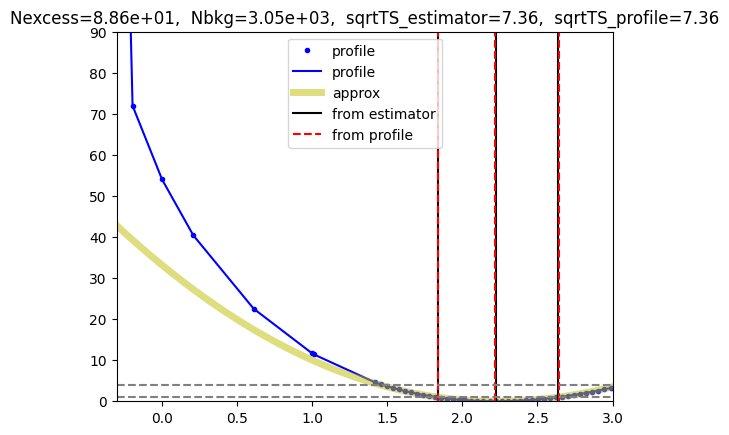

In [36]:
indx, indy, inde =[int(_) for _ in res.norm.geom.center_pix]
run_checks(indx, indy, xl=[-0.3,3], yl=[0, 90], prints=False)


but norm, errn, errp, ul are consitent with the gaussian expectation...

from estimator
errn 0.3853055894872255
norm 2.22115528930931
err 0.40255960598657126
errp 0.413804794675118
ul 3.0775281874750133
from profile
errn 0.37999999999999984
norm 2.2199999999999998
err 0.40000000000000013
errp 0.4200000000000005
ul 3.08
from profile approximation
errn 0.37999999999999984
norm 2.2199999999999998
err 0.40000000000000013
errp 0.4200000000000005
ul 3.04


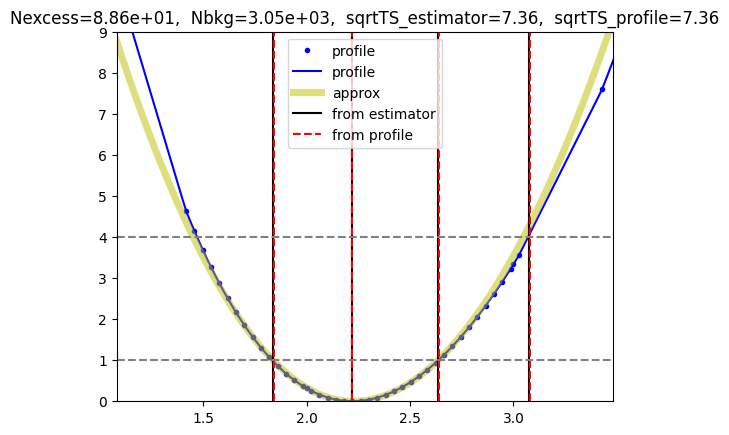

In [37]:
run_checks(indx, indy)


...except in the low counts regime:


In [38]:
np.nanmin(res.npred_background)

341.7429701264249

from estimator
errn 0.6191745106534478
norm -0.41570111034754864
err 0.812018883250585
errp 0.34474180589508535
ul 0.7081955997259871
from profile
errn 0.342
norm -0.658
err 0.44300000000000006
errp 0.544
ul 0.676
from profile approximation
errn 0.624
norm -0.41600000000000004
err 0.4845
errp 0.34500000000000003
ul 0.274


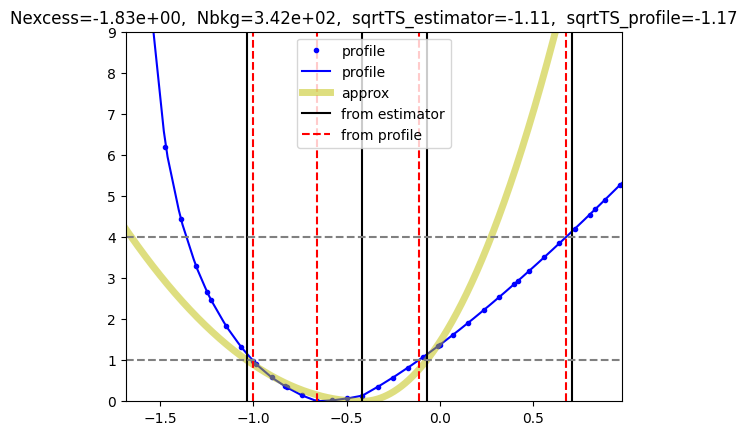

In [39]:
inde, indx, indy = np.where(res.npred_background==np.nanmin(res.npred_background))
#run_checks(ind, yl=None, xl=[-0.5,0.5])
run_checks(indx[0], indy[0])


Here both norm, errors and ul are not consistent with the gaussian error approximation. \
However even there the profile contains valuable information, that we loose if we quote only upper limits !

See plots in https://github.com/gammapy/gammapy/discussions/5341 for more examples.

In the low counts regime we also note a differences between the Brentq method used by default in the estimator and the profile estimates. \
The norm estimated by Brentq is biased upward and tends to the upper limit and does not match the one found we computing the likelood profile. This effect worsen as the counts decrease. \
I would recommend to use the profile in that case.

# Joint and combined TSmap for datasets



Joint TSmap result from the default estimator

In [40]:
%%time
res_joint = estimator_ref.run(datasets)

sqrt_ts_joint = res_joint["sqrt_ts"]

CPU times: user 50 s, sys: 354 ms, total: 50.4 s
Wall time: 50.3 s


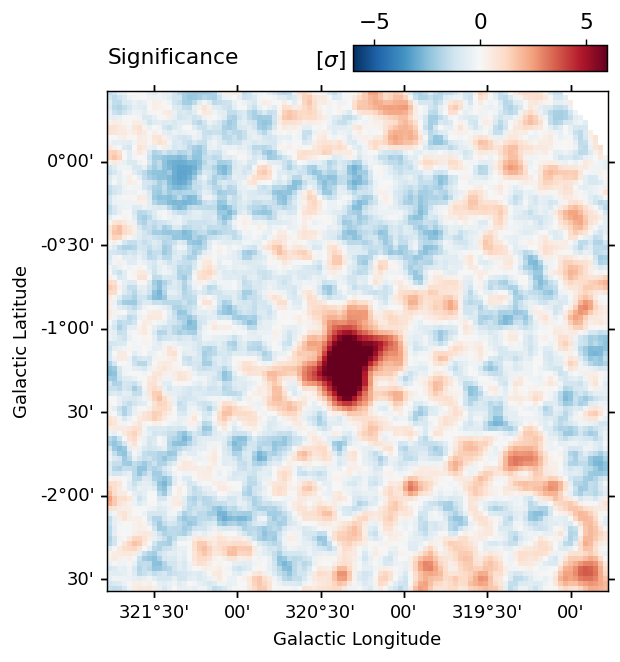

In [41]:
fig = plt.figure(figsize=(13,5), dpi=130)
ax = res_joint["sqrt_ts"].plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

Joint TSmap results from the estimator with profile computation

In [42]:
%%time
res_joint_profile = estimator.run(datasets)

CPU times: user 1min 32s, sys: 1.49 s, total: 1min 34s
Wall time: 1min 34s


In [43]:
%%time
res_joint_profile = get_flux_map_from_profile(res_joint_profile)

sqrt_ts_joint_profile = res_joint_profile["sqrt_ts"]

CPU times: user 7.18 s, sys: 5.6 s, total: 12.8 s
Wall time: 13.9 s


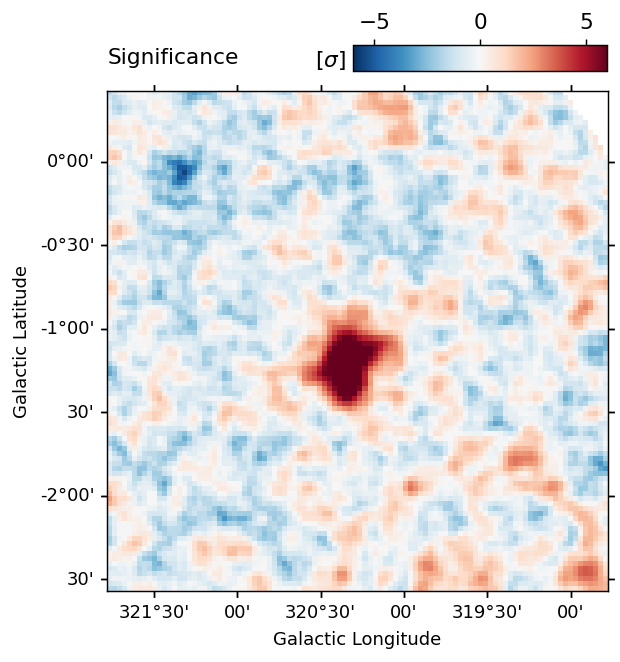

In [44]:
fig = plt.figure(figsize=(13,5), dpi=130)
ax = sqrt_ts_joint_profile.plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

In [45]:
print("sqrt(TS) max")
print("stacked", np.nanmax(sqrt_ts_stacked))
print("joint", np.nanmax(sqrt_ts_joint))
print("joint_profile", np.nanmax(sqrt_ts_joint_profile))


sqrt(TS) max
stacked 10.421609792878654
joint 9.955063077633817
joint_profile 9.955024859522599


In [46]:
diff = sqrt_ts_joint-sqrt_ts_joint_profile

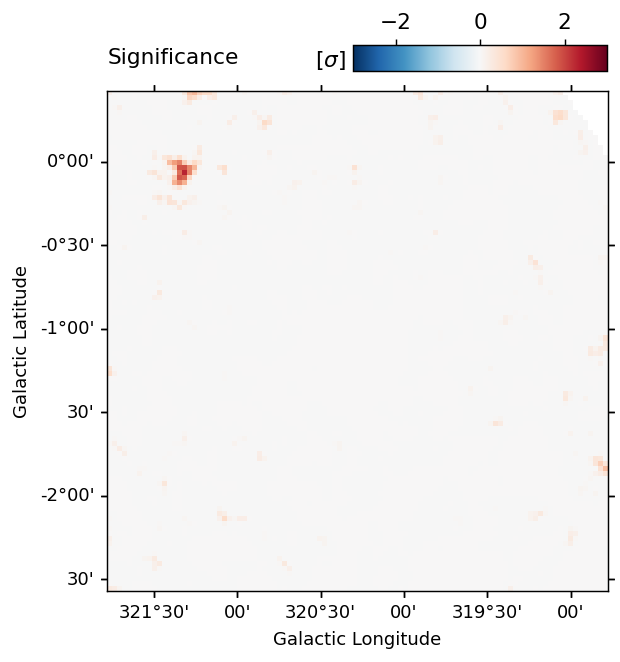

In [47]:
fig = plt.figure(figsize=(13,5), dpi=130)
ax = diff.plot(clim=[-3,3], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

We can see very few differences between the Brentq method used by defalut in the estimator and the profile estimate. \
From tests on the HAWC datasets including several event types with very different IRFs it seems that differences are more prononced. \
I would recommend to use systematically the profile for the joints datasets estimates. 

In [48]:
del res_ref, res_profile, res_profile_approx, result_gauss_approx, stacked, res_joint_profile

# Flux maps combination

Does the TSmap computed by combining the result of the estimator for each dataset match the joint TSmap ?

This takes a lot of memory, don't run with all 20 datasets.


Run estimators for each dataset without profile

In [49]:
%%time
results = []
for kd , d in enumerate(datasets):
    res = estimator_ref.run(d)
    results.append(res)

CPU times: user 50.5 s, sys: 482 ms, total: 51 s
Wall time: 50.7 s


In [50]:
%%time
#combine flux maps using symetric gaussian approximation (analytic)
result_combined_gauss = combine_flux_maps(results, method="gaussian_errors")
toogle_output()


CPU times: user 24.7 ms, sys: 1.58 ms, total: 26.3 ms
Wall time: 26.3 ms


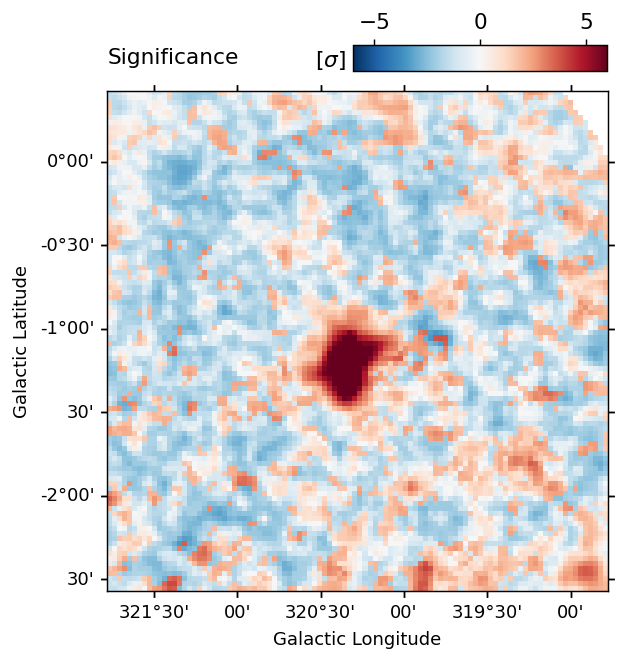

In [51]:
sqrt_ts_combined_gauss = result_combined_gauss["sqrt_ts"]
del result_combined_gauss

fig = plt.figure(figsize=(13,5), dpi=130)
ax = sqrt_ts_combined_gauss.plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

In [52]:
%%time
#combine flux maps using likelihood profile approximation derived from asymetric gaussian (sampling)
result_combined_gauss_asym = combine_flux_maps(results, method="distrib")
toogle_output()


/Users/qremy/Work/GitHub/gammapy/gammapy/estimators/utils.py:1041: RuntimeWarning: divide by zero encountered in log
  stat_approx.data[ij, :, il, ik] = -2 * np.log(
/Users/qremy/Work/GitHub/gammapy/gammapy/estimators/utils.py:1041: RuntimeWarning: divide by zero encountered in log
  stat_approx.data[ij, :, il, ik] = -2 * np.log(
/Users/qremy/Work/GitHub/gammapy/gammapy/estimators/utils.py:1041: RuntimeWarning: divide by zero encountered in log
  stat_approx.data[ij, :, il, ik] = -2 * np.log(
/Users/qremy/Work/GitHub/gammapy/gammapy/estimators/utils.py:1041: RuntimeWarning: divide by zero encountered in log
  stat_approx.data[ij, :, il, ik] = -2 * np.log(


CPU times: user 44.8 s, sys: 30.5 s, total: 1min 15s
Wall time: 1min 19s


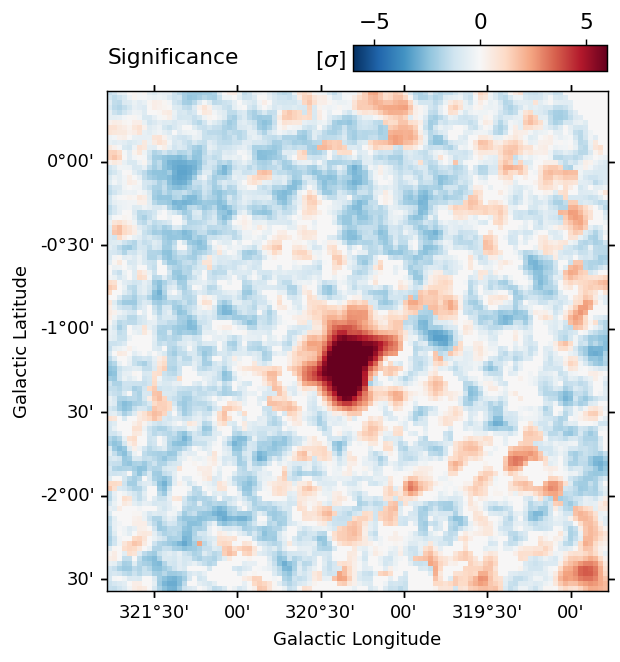

In [53]:
sqrt_ts_combined_gauss_asym = result_combined_gauss_asym["sqrt_ts"]
del result_combined_gauss_asym

fig = plt.figure(figsize=(13,5), dpi=130)
ax = sqrt_ts_combined_gauss_asym.plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

Run estimators for each dataset with profile

In [54]:
%%time
results_profile = []
for kd , d in enumerate(datasets):
    res_profile = estimator.run(d)
    res_profile = get_flux_map_from_profile(res_profile)
    results_profile.append(res_profile)

CPU times: user 2min, sys: 23.8 s, total: 2min 24s
Wall time: 2min 29s


In [55]:
%%time
#combine flux maps using likelihood profile
result_combined_profile = combine_flux_maps(results_profile, method="profile")


CPU times: user 7.68 s, sys: 7.52 s, total: 15.2 s
Wall time: 17.8 s


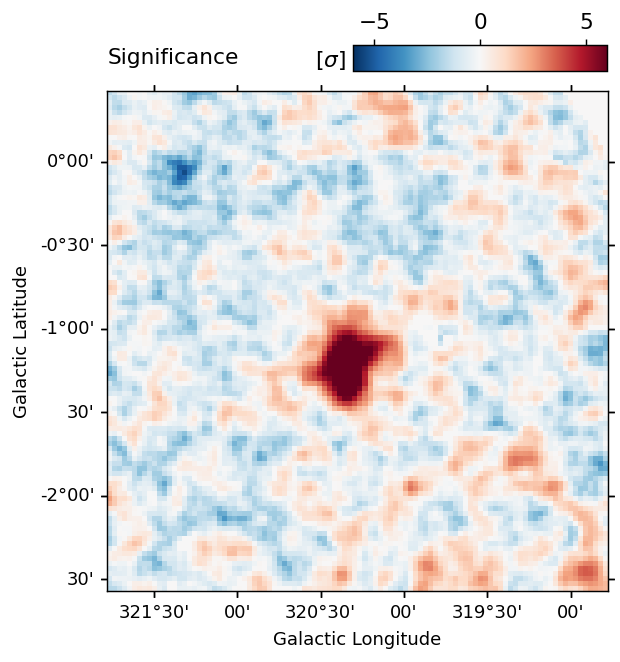

In [56]:
sqrt_ts_combined_profile = result_combined_profile["sqrt_ts"]

fig = plt.figure(figsize=(13,5), dpi=130)
ax = sqrt_ts_combined_profile.plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

In [57]:
print("sqrt(TS) max")
print("stacked", np.nanmax(sqrt_ts_stacked))
print("joint", np.nanmax(sqrt_ts_joint))
print("joint_profile", np.nanmax(sqrt_ts_joint_profile))
print("gaussian_approx", np.nanmax(sqrt_ts_combined_gauss))
print("profile_approx", np.nanmax(sqrt_ts_combined_gauss_asym))
print("profile_combined", np.nanmax(sqrt_ts_combined_profile))


sqrt(TS) max
stacked 10.421609792878654
joint 9.955063077633817
joint_profile 9.955024859522599
gaussian_approx 10.010662637297095
profile_approx 9.992858817257579
profile_combined 9.954508231451248


Is stacked dataset TS biased upward ???

In [58]:
diff = sqrt_ts_joint_profile-sqrt_ts_combined_profile

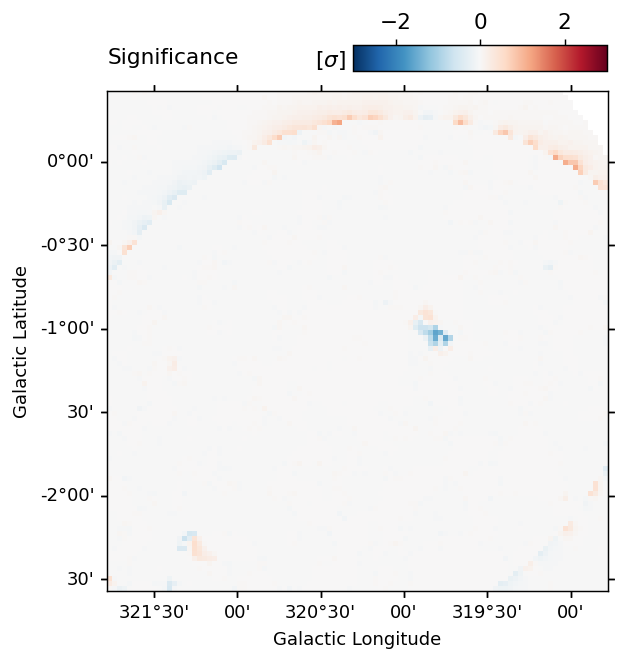

In [59]:
fig = plt.figure(figsize=(13,5), dpi=130)
ax = diff.plot(clim=[-3,3], cmap=plt.cm.RdBu_r)
im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
plt.title(r"Significance", loc="left", fontsize=12, pad=15)
cb_ax = fig.add_axes([.51, .91, .15, 0.04])
cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
cb.ax.xaxis.set_ticks_position("top")
cb.ax.xaxis.set_label_position("top")
cb.ax.tick_params(axis="both", which="major", labelsize=12)
cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);

Very few difference between joint and combined TSmap \
Maybe edges effect due to the difference in pad_width for joint ?

# TSmap per dataset outside exclusion region

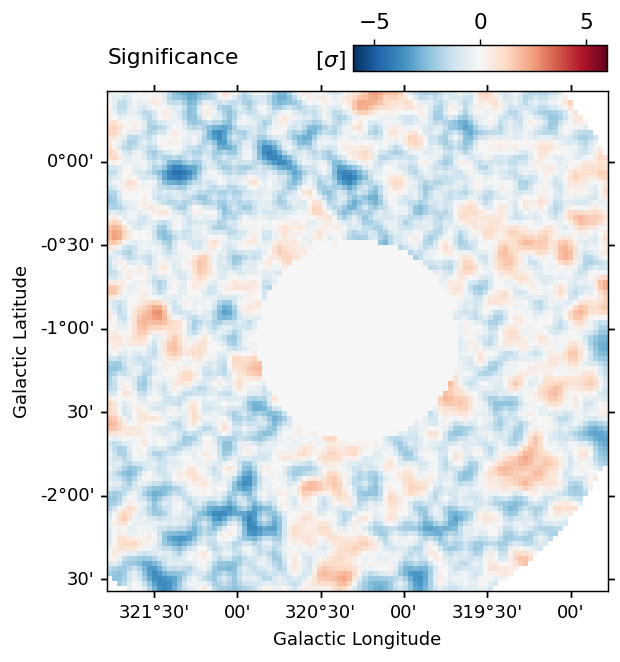

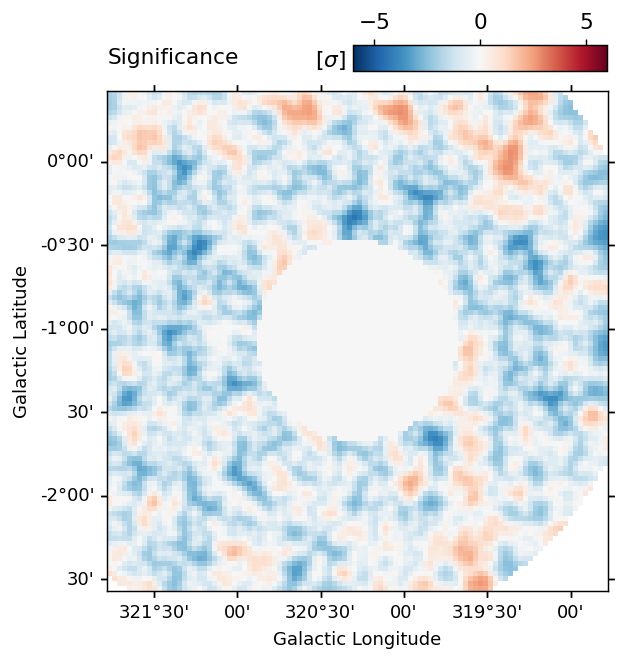

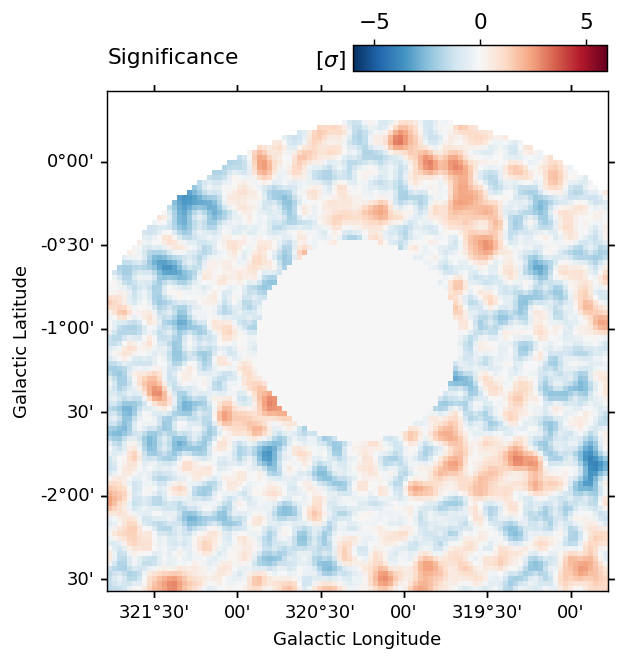

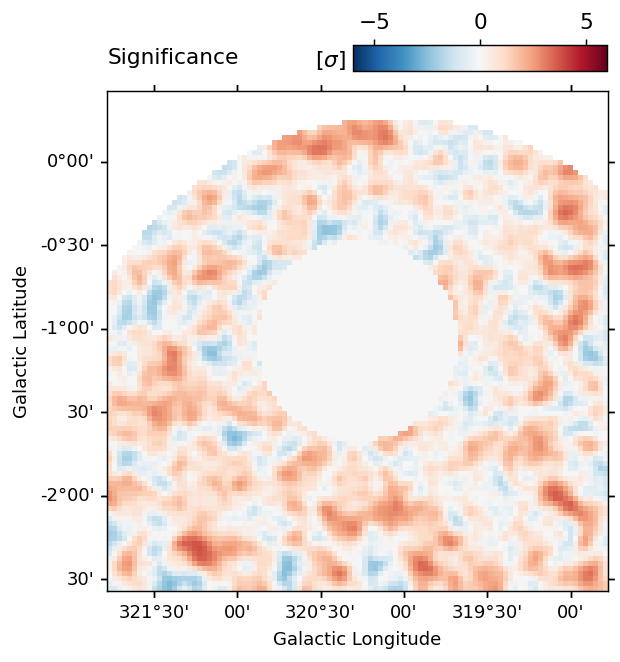

In [60]:
mask = exclusion_mask.sum_over_axes()
mask.data = mask.data>0
for r in results_profile:
    fig = plt.figure(figsize=(13,5), dpi=130)
    ax = (r["sqrt_ts"]*mask).plot(clim=[-6,6], cmap=plt.cm.RdBu_r)
    im = [obj for obj in ax.get_children() if isinstance(obj, mpl.image.AxesImage)][0]
    plt.title(r"Significance", loc="left", fontsize=12, pad=15)
    cb_ax = fig.add_axes([.51, .91, .15, 0.04])
    cb = fig.colorbar(im, cax=cb_ax, orientation='horizontal')  
    cb.ax.xaxis.set_ticks_position("top")
    cb.ax.xaxis.set_label_position("top")
    cb.ax.tick_params(axis="both", which="major", labelsize=12)
    cb.ax.set_xlabel(r"[$\sigma$]", fontsize=12, labelpad=-30, x=-0.09);
    